## To look at distribution of tripos cells in Radbot horizontal data


In [6]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("../IFCBData/SeaTrac/subsampled/radbot_ios/merged/D20230626T133109_IFCB110_merged_keepzero.csv")


In [10]:
from pathlib import Path
import pandas as pd

# -----------------------------
# User inputs
# -----------------------------
data_dir = Path("../IFCBData/SeaTrac/subsampled/radbot_ios/merged/")
output_csv = Path("../IFCBData/SeaTrac/subsampled/Tripos_muelleri_master.csv")

score_col = "Tripos_muelleri"
alpha = 0.9

# Optional: change this pattern if needed
file_pattern = "*.csv"

# -----------------------------
# Sweep files and collect matches
# -----------------------------
matched_rows = []

for file in data_dir.glob(file_pattern):
    df = pd.read_csv(file)

    if score_col not in df.columns:
        print(f"Skipping {file.name}: missing column {score_col}")
        continue

    df[score_col] = pd.to_numeric(df[score_col], errors="coerce")

    matched = df[df[score_col] > alpha].copy()

    if matched.empty:
        continue

    matched["source_file"] = file.name
    matched["source_path"] = str(file)

    matched_rows.append(matched)

# -----------------------------
# Compile master dataframe
# -----------------------------
if matched_rows:
    master_df = pd.concat(matched_rows, ignore_index=True)
else:
    master_df = pd.DataFrame()

# Save output
master_df.to_csv(output_csv, index=False)

print(f"Matched {len(master_df)} rows with {score_col} > {alpha}")
print(f"Saved to {output_csv}")

Matched 878 rows with Tripos_muelleri > 0.9
Saved to ../IFCBData/SeaTrac/subsampled/Tripos_muelleri_master.csv


In [18]:
df = pd.read_csv("../IFCBData/SeaTrac/subsampled/Tripos_muelleri_master.csv")


In [14]:
print(df.head())    


   trigger#  RoiNumber      PMTB    ADCtime    RunTime  InhibitTime  \
0         2          2  2.146278   9.468754   9.492296     0.085503   
1         4          4  2.038252  25.103766  25.126821     0.254264   
2         5          5  1.685771  32.505156  32.529421     0.340905   
3         9          9  2.114528  81.093912  81.119592     0.685781   
4        12         12  0.508774  90.534216  90.560009     0.940577   

   InhibitTimeDiff  VolumeAnalyzed  RoiType  RoiHeight  ...  fiber  \
0         0.085503        0.039195        1        508  ...    0.0   
1         0.084110        0.103636        1        580  ...    0.0   
2         0.086641        0.134119        1        532  ...    0.0   
3         0.087810        0.335141        1        548  ...    0.0   
4         0.085193        0.373414        1        476  ...    0.0   

   fiber_TAG_external_detritus  flagellate flagellate_morphotype1  \
0                          0.0         0.0                    0.0   
1             

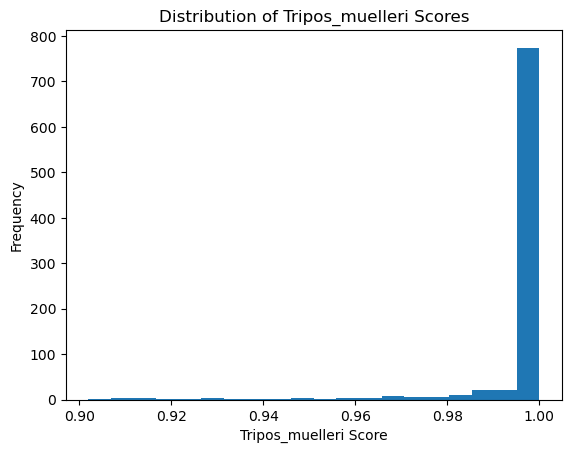

In [16]:
plt.hist(df["Tripos_muelleri"], bins=20)
plt.xlabel("Tripos_muelleri Score")
plt.ylabel("Frequency")
plt.title("Distribution of Tripos_muelleri Scores")
plt.show()  

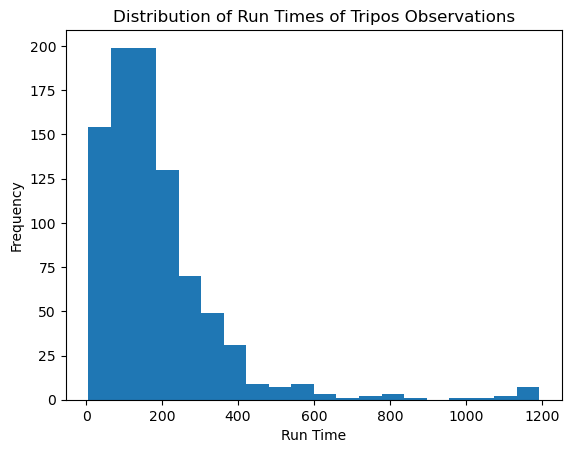

In [19]:
plt.hist(df["RunTime"], bins=20)
plt.xlabel("Run Time")
plt.ylabel("Frequency")
plt.title("Distribution of Run Times of Tripos Observations")
plt.savefig("../Figs/TriposRunTimeDistribution.png")
plt.show()  

KS statistic: 0.6216342505955722
p-value: 0.0


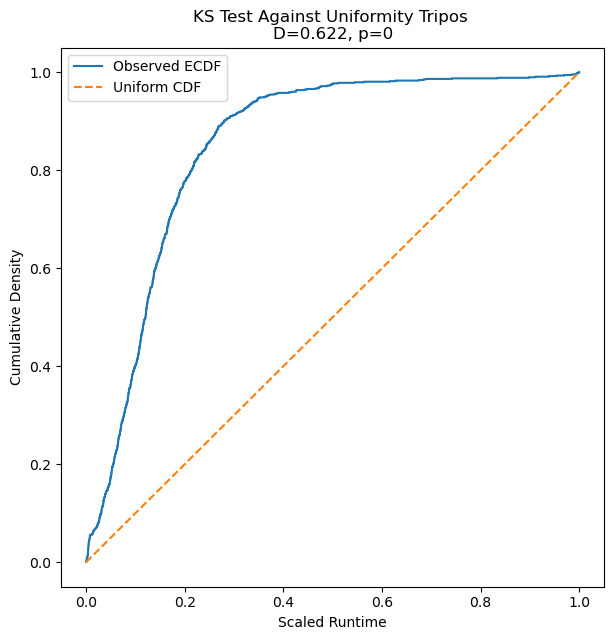

In [ ]:
### Representing this graphically with CDF plots

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest

# -----------------------------------
# Example observed data
# -----------------------------------
data = np.array(df["RunTime"])

# Scale to [0,1]
scaled = (data - data.min()) / (data.max() - data.min())

# -----------------------------------
# Empirical CDF
# -----------------------------------
x = np.sort(scaled)

n = len(x)

ecdf = np.arange(1, n + 1) / n

# -----------------------------------
# Theoretical uniform CDF
# -----------------------------------
theoretical_x = np.linspace(0, 1, 1000)
theoretical_cdf = theoretical_x

# -----------------------------------
# KS test
# -----------------------------------
ks_stat, p = kstest(scaled, 'uniform')

print("KS statistic:", ks_stat)
print("p-value:", p)

# -----------------------------------
# Plot
# -----------------------------------
plt.figure(figsize=(7,7))

# observed ECDF
plt.step(
    x,
    ecdf,
    where='post',
    label='Observed ECDF'
)

# theoretical uniform CDF
plt.plot(
    theoretical_x,
    theoretical_cdf,
    linestyle='--',
    label='Uniform CDF'
)

plt.xlabel("Scaled Runtime")
plt.ylabel("Cumulative Density")

plt.title(
    f"KS Test Against Uniformity Tripos \nD={ks_stat:.3f}, p={p:.3g}"
)

plt.legend()
#plt.savefig("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/Figs/Radbot_ios_Subsample/KS_test_tripos.png", dpi=300)

plt.show()

## Is this different from just all rois?


Loaded D20230627T001537_IFCB110_merged_keepzero.csv: 52 values
Loaded D20230709T120912_IFCB110_merged_keepzero.csv: 514 values
Loaded D20230704T121818_IFCB110_merged_keepzero.csv: 601 values
Loaded D20230717T062247_IFCB110_merged_keepzero.csv: 565 values
Loaded D20230706T061014_IFCB110_merged_keepzero.csv: 208 values
Loaded D20230708T000552_IFCB110_merged_keepzero.csv: 391 values
Loaded D20230709T001755_IFCB110_merged_keepzero.csv: 463 values
Loaded D20230710T180254_IFCB110_merged_keepzero.csv: 490 values
Loaded D20230716T180450_IFCB110_merged_keepzero.csv: 535 values
Loaded D20230718T002220_IFCB110_merged_keepzero.csv: 466 values
Loaded D20230706T213722_IFCB110_merged_keepzero.csv: 441 values
Loaded D20230713T001301_IFCB110_merged_keepzero.csv: 332 values
Loaded D20230714T002134_IFCB110_merged_keepzero.csv: 541 values
Loaded D20230718T121652_IFCB110_merged_keepzero.csv: 573 values
Loaded D20230629T181525_IFCB110_merged_keepzero.csv: 237 values
Loaded D20230703T014826_IFCB110_merged_ke

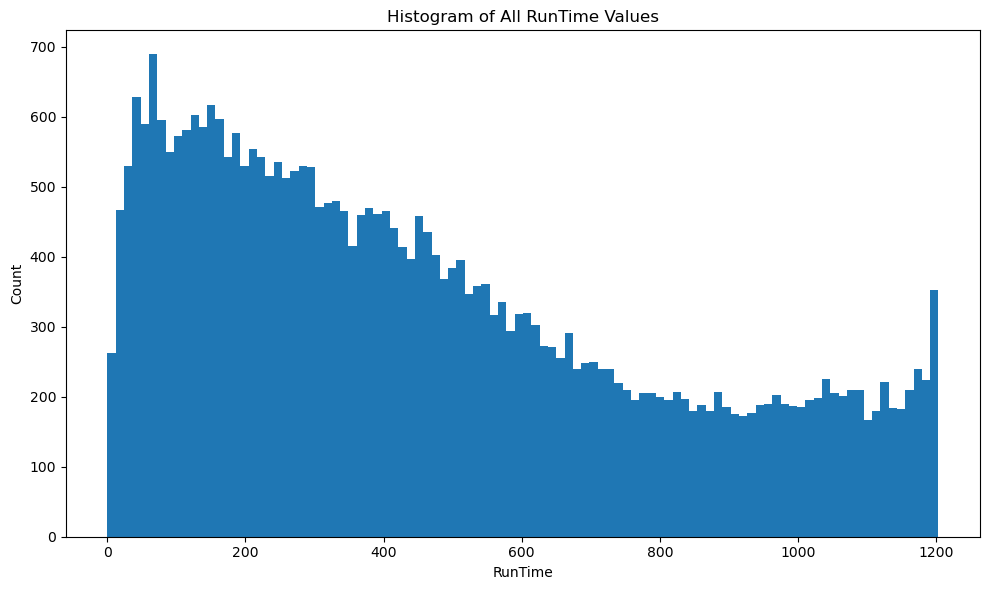

In [21]:

# -----------------------------
# User inputs
# -----------------------------
data_dir = Path("../IFCBData/SeaTrac/subsampled/radbot_ios/merged/")

runtime_col = "RunTime"
file_pattern = "*.csv"

# -----------------------------
# Collect RunTime values
# -----------------------------
all_runtimes = []

for file in data_dir.glob(file_pattern):
    try:
        df = pd.read_csv(file, usecols=[runtime_col])

        # Convert to numeric and drop bad values
        runtimes = pd.to_numeric(df[runtime_col], errors="coerce").dropna()

        all_runtimes.append(runtimes)

        print(f"Loaded {file.name}: {len(runtimes)} values")

    except Exception as e:
        print(f"Skipping {file.name}: {e}")

# -----------------------------
# Combine into one Series
# -----------------------------
if all_runtimes:
    runtime_series = pd.concat(all_runtimes, ignore_index=True)
else:
    raise ValueError("No valid RunTime data found.")

print(f"\nTotal RunTime values: {len(runtime_series)}")

# -----------------------------
# Plot histogram
# -----------------------------
plt.figure(figsize=(10, 6))

plt.hist(runtime_series, bins=100)

plt.xlabel("RunTime")
plt.ylabel("Count")
plt.title("Histogram of All RunTime Values")

plt.tight_layout()
#plt.savefig("../Figs/chukchi/AllRunTimesHist.png")
plt.show()

KS statistic: 0.19355756480948183
p-value: 0.0


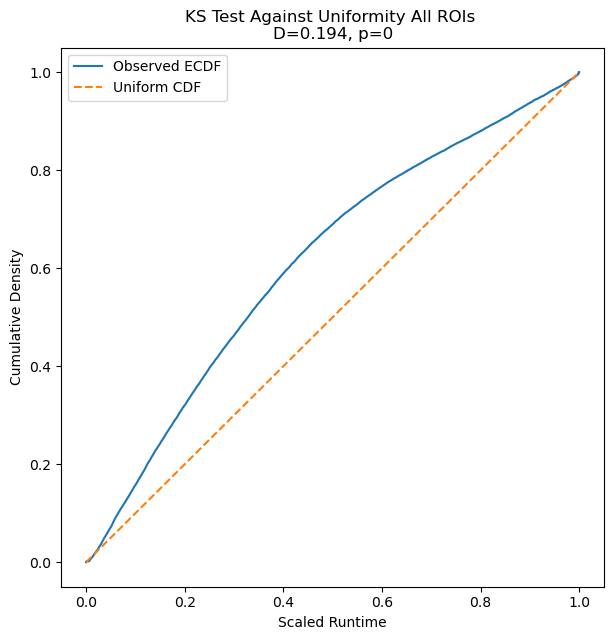

In [ ]:
### Representing this graphically with CDF plots

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest

# -----------------------------------
# Example observed data
# -----------------------------------
data = np.array(runtime_series)

# Scale to [0,1]
scaled = (data - data.min()) / (data.max() - data.min())

# -----------------------------------
# Empirical CDF
# -----------------------------------
x = np.sort(scaled)

n = len(x)

ecdf = np.arange(1, n + 1) / n

# -----------------------------------
# Theoretical uniform CDF
# -----------------------------------
theoretical_x = np.linspace(0, 1, 1000)
theoretical_cdf = theoretical_x

# -----------------------------------
# KS test
# -----------------------------------
ks_stat, p = kstest(scaled, 'uniform')

print("KS statistic:", ks_stat)
print("p-value:", p)

# -----------------------------------
# Plot
# -----------------------------------
plt.figure(figsize=(7,7))

# observed ECDF
plt.step(
    x,
    ecdf,
    where='post',
    label='Observed ECDF'
)

# theoretical uniform CDF
plt.plot(
    theoretical_x,
    theoretical_cdf,
    linestyle='--',
    label='Uniform CDF'
)

plt.xlabel("Scaled Runtime")
plt.ylabel("Cumulative Density")

plt.title(
    f"KS Test Against Uniformity All ROIs \nD={ks_stat:.3f}, p={p:.3g}"
)

plt.legend()
#plt.savefig("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/Figs/Radbot_ios_Subsample/KS_test_allROIS.png", dpi=300)

plt.show()

## Creating an outgroup there is no obvious other species but basically everything that isnt tripos is small and rare 
 Just change logic to select things that are less than alpha 0.9 of class score

In [2]:
# -----------------------------
# User inputs
# -----------------------------
data_dir = Path("../IFCBData/SeaTrac/subsampled/radbot_ios/merged/")
output_csv = Path("../IFCBData/SeaTrac/subsampled/not_tripos_master.csv")

score_col = "Tripos_muelleri"
alpha = 0.9

# Optional: change this pattern if needed
file_pattern = "*.csv"

# -----------------------------
# Sweep files and collect matches
# -----------------------------
matched_rows = []

for file in data_dir.glob(file_pattern):
    df = pd.read_csv(file)

    if score_col not in df.columns:
        print(f"Skipping {file.name}: missing column {score_col}")
        continue

    df[score_col] = pd.to_numeric(df[score_col], errors="coerce")

    matched = df[df[score_col] < alpha].copy() # Get rows where Tripos_muelleri <= 0.9 so not tripos

    if matched.empty:
        continue

    matched["source_file"] = file.name
    matched["source_path"] = str(file)

    matched_rows.append(matched)

# -----------------------------
# Compile master dataframe
# -----------------------------
if matched_rows:
    master_df = pd.concat(matched_rows, ignore_index=True)
else:
    master_df = pd.DataFrame()

# Save output
master_df.to_csv(output_csv, index=False)

print(f"Matched {len(master_df)} rows with {score_col} < {alpha}")
print(f"Saved to {output_csv}")

Matched 33841 rows with Tripos_muelleri < 0.9
Saved to ../IFCBData/SeaTrac/subsampled/not_tripos_master.csv


In [26]:
df = pd.read_csv("../IFCBData/SeaTrac/subsampled/not_tripos_master.csv")
print(df.head())

   trigger#  RoiNumber      PMTB    ADCtime    RunTime  InhibitTime  \
0         3          3  0.004349  18.182823  18.206510     0.170154   
1         6          6 -0.000374  55.007388  55.032044     0.426721   
2         7          7 -0.001228  57.129065  57.152752     0.510755   
3         8          8  0.016707  68.979647  69.004826     0.597971   
4        10         10 -0.004710  85.809036  85.832830     0.768084   

   InhibitTimeDiff  VolumeAnalyzed  RoiType  RoiHeight  ...         fiber  \
0         0.084651        0.075151        1         60  ...  8.100000e-06   
1         0.085816        0.227522        1         76  ...  6.510000e-05   
2         0.084034        0.236008        1        140  ...  6.000000e-08   
3         0.087216        0.285029        1         92  ...  6.000000e-08   
4         0.082303        0.354436        1         52  ...  8.820000e-05   

   fiber_TAG_external_detritus  flagellate flagellate_morphotype1  \
0                 8.000000e-07    0.02260

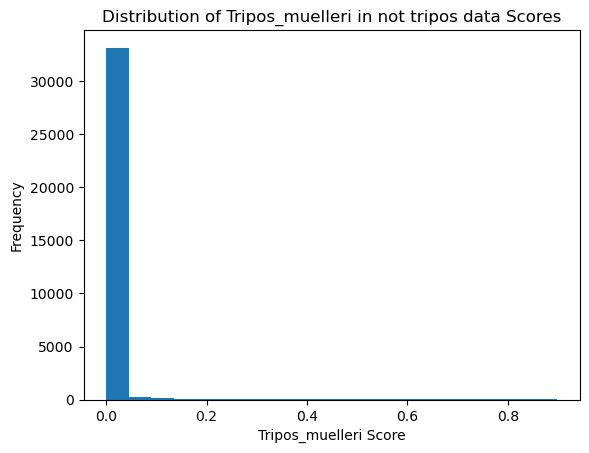

In [27]:
plt.hist(df["Tripos_muelleri"], bins=20)
plt.xlabel("Tripos_muelleri Score")
plt.ylabel("Frequency")
plt.title("Distribution of Tripos_muelleri in not tripos data Scores")
plt.show()  

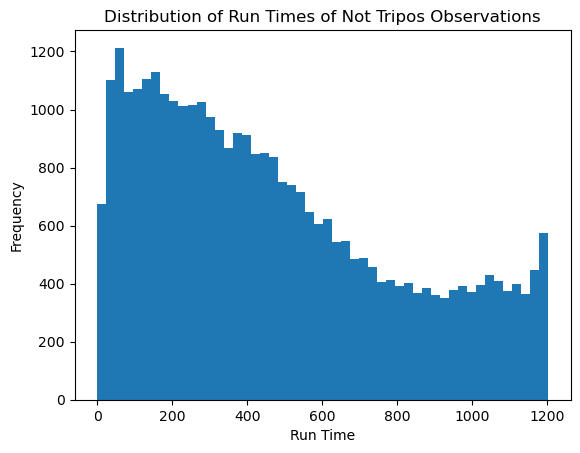

In [28]:
plt.hist(df["RunTime"], bins=50)
plt.xlabel("Run Time")
plt.ylabel("Frequency")
plt.title("Distribution of Run Times of Not Tripos Observations")
#plt.savefig("../Figs/Radbot_ios_Subsample/NotTriposRunTimeDistribution.png", dpi=300)
plt.show()  

KS statistic: 0.1854064432779896
p-value: 0.0


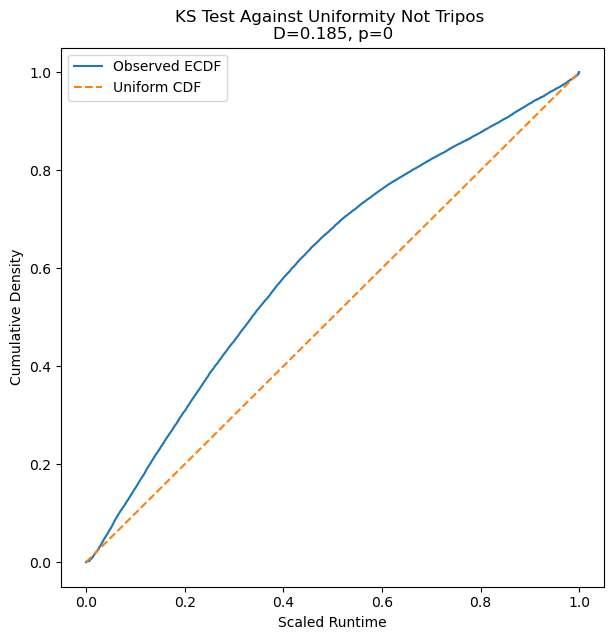

In [ ]:
### Representing this graphically with CDF plots

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest

# -----------------------------------
# Example observed data
# -----------------------------------
data = np.array(df["RunTime"])

# Scale to [0,1]
scaled = (data - data.min()) / (data.max() - data.min())

# -----------------------------------
# Empirical CDF
# -----------------------------------
x = np.sort(scaled)

n = len(x)

ecdf = np.arange(1, n + 1) / n

# -----------------------------------
# Theoretical uniform CDF
# -----------------------------------
theoretical_x = np.linspace(0, 1, 1000)
theoretical_cdf = theoretical_x

# -----------------------------------
# KS test
# -----------------------------------
ks_stat, p = kstest(scaled, 'uniform')

print("KS statistic:", ks_stat)
print("p-value:", p)

# -----------------------------------
# Plot
# -----------------------------------
plt.figure(figsize=(7,7))

# observed ECDF
plt.step(
    x,
    ecdf,
    where='post',
    label='Observed ECDF'
)

# theoretical uniform CDF
plt.plot(
    theoretical_x,
    theoretical_cdf,
    linestyle='--',
    label='Uniform CDF'
)

plt.xlabel("Scaled Runtime")
plt.ylabel("Cumulative Density")

plt.title(
    f"KS Test Against Uniformity Not Tripos \nD={ks_stat:.3f}, p={p:.3g}"
)

plt.legend()
#plt.savefig("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/Figs/Radbot_ios_Subsample/KS_test_NOT_Tripos.png", dpi=300)

plt.show()